In [ ]:
import os 
import pandas as pd
from pathlib import Path 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
MASTER_DIR = Path(r"D:\Automotive\Race Strategy Decision Support System (RSDSS)\Race-Strategy-Decision-Support-System-RSDSS-\Data\Processed\Master\Master_Dataset.csv")
df = pd.read_csv(MASTER_DIR)

In [3]:
df = df[df["ValidLap"]].copy()

In [4]:
print(f"Drivers: {df['Driver'].nunique()}")
print(sorted(df["Driver"].unique()))

Drivers: 31
['ALB', 'ALO', 'ANT', 'BEA', 'BOR', 'BOT', 'COL', 'DEV', 'DOO', 'GAS', 'HAD', 'HAM', 'HUL', 'LAT', 'LAW', 'LEC', 'MAG', 'MSC', 'NOR', 'OCO', 'PER', 'PIA', 'RIC', 'RUS', 'SAI', 'SAR', 'STR', 'TSU', 'VER', 'VET', 'ZHO']


In [5]:
print(f"Teams: {df['Team'].nunique()}")
print(sorted(df["Team"].unique()))

Teams: 13
['Alfa Romeo', 'AlphaTauri', 'Alpine', 'Aston Martin', 'Ferrari', 'Haas F1 Team', 'Kick Sauber', 'McLaren', 'Mercedes', 'RB', 'Racing Bulls', 'Red Bull Racing', 'Williams']


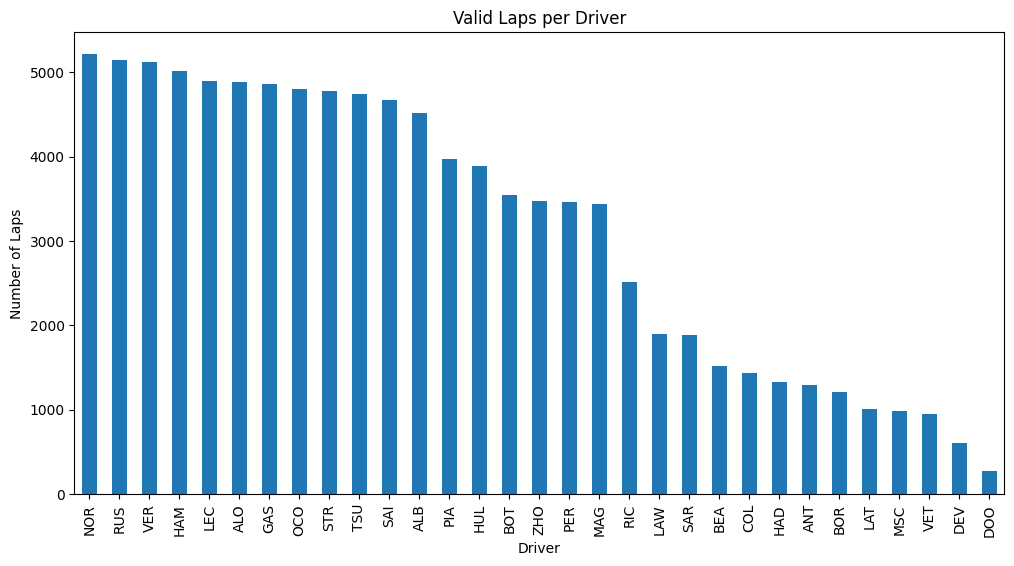

In [6]:
driver_laps = (
    df.groupby("Driver")
      .size()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
driver_laps.plot(kind="bar")

plt.title("Valid Laps per Driver")
plt.ylabel("Number of Laps")

plt.show()

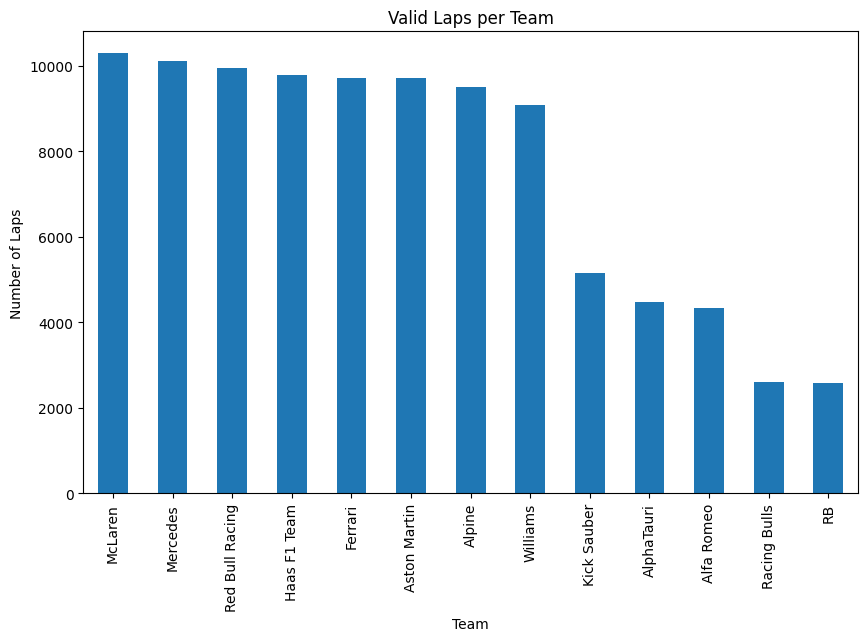

In [7]:
team_laps = (
    df.groupby("Team")
      .size()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
team_laps.plot(kind="bar")

plt.title("Valid Laps per Team")
plt.ylabel("Number of Laps")

plt.show()

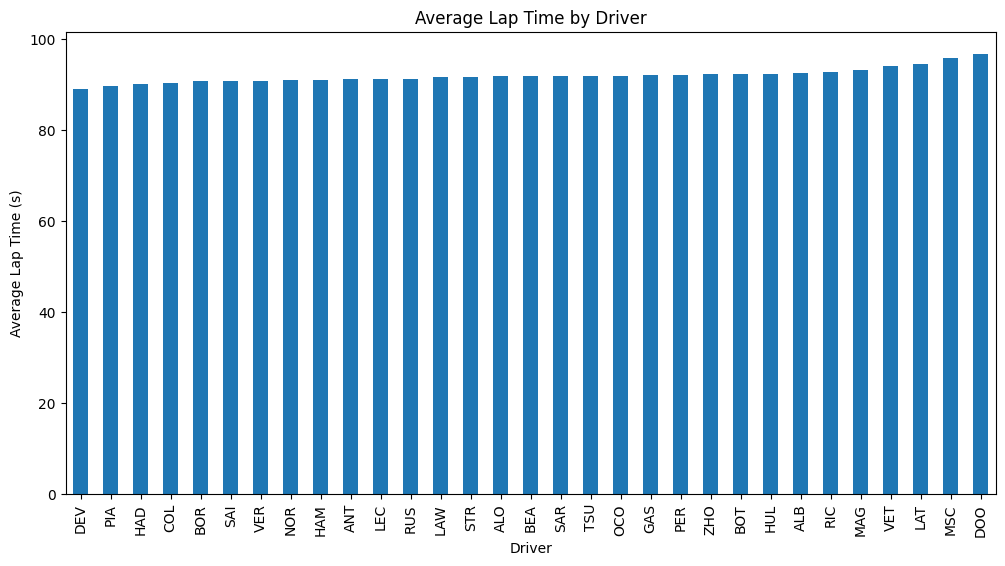

In [8]:
avg_driver = (
    df.groupby("Driver")["LapTime_Seconds"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(12,6))
avg_driver.plot(kind="bar")

plt.ylabel("Average Lap Time (s)")
plt.title("Average Lap Time by Driver")

plt.show()

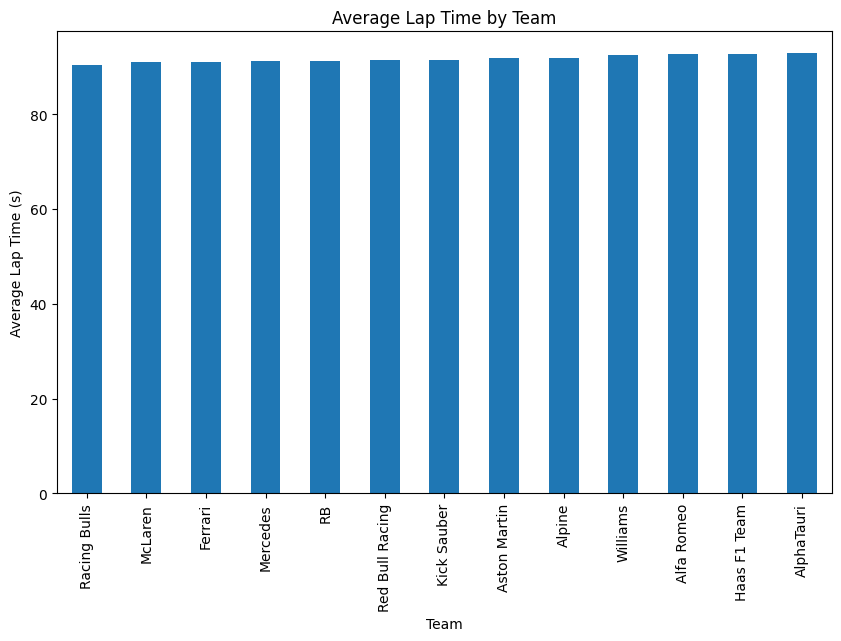

In [9]:
avg_team = (
    df.groupby("Team")["LapTime_Seconds"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,6))
avg_team.plot(kind="bar")

plt.ylabel("Average Lap Time (s)")
plt.title("Average Lap Time by Team")

plt.show()

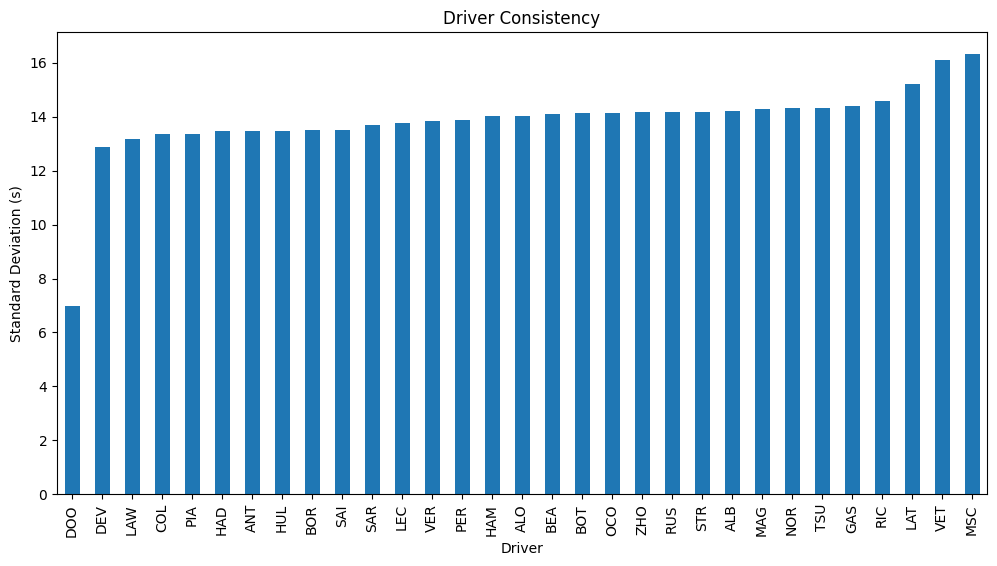

In [10]:
consistency = (
    df.groupby("Driver")["LapTime_Seconds"]
      .std()
      .sort_values()
)

plt.figure(figsize=(12,6))
consistency.plot(kind="bar")

plt.ylabel("Standard Deviation (s)")
plt.title("Driver Consistency")

plt.show()

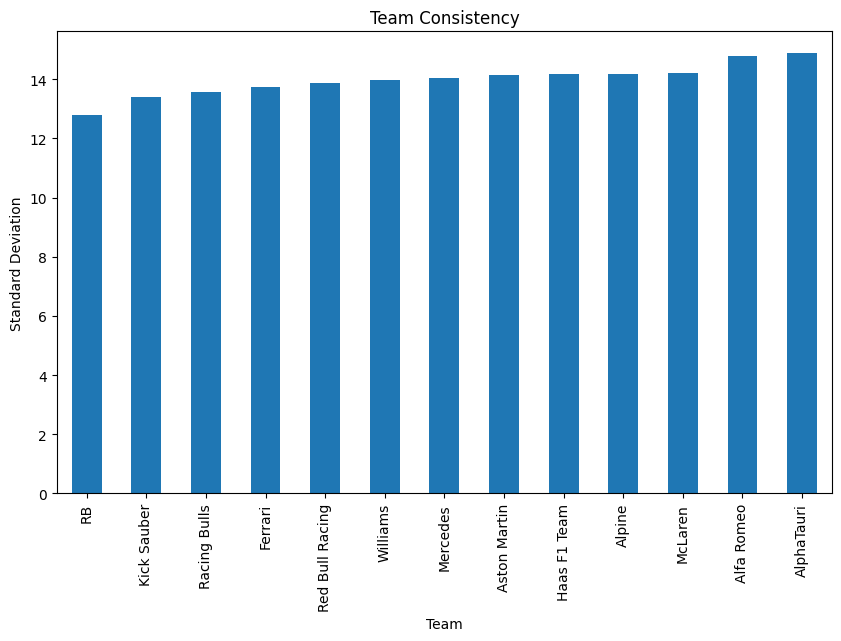

In [11]:
team_std = (
    df.groupby("Team")["LapTime_Seconds"]
      .std()
      .sort_values()
)

plt.figure(figsize=(10,6))
team_std.plot(kind="bar")

plt.ylabel("Standard Deviation")
plt.title("Team Consistency")

plt.show()

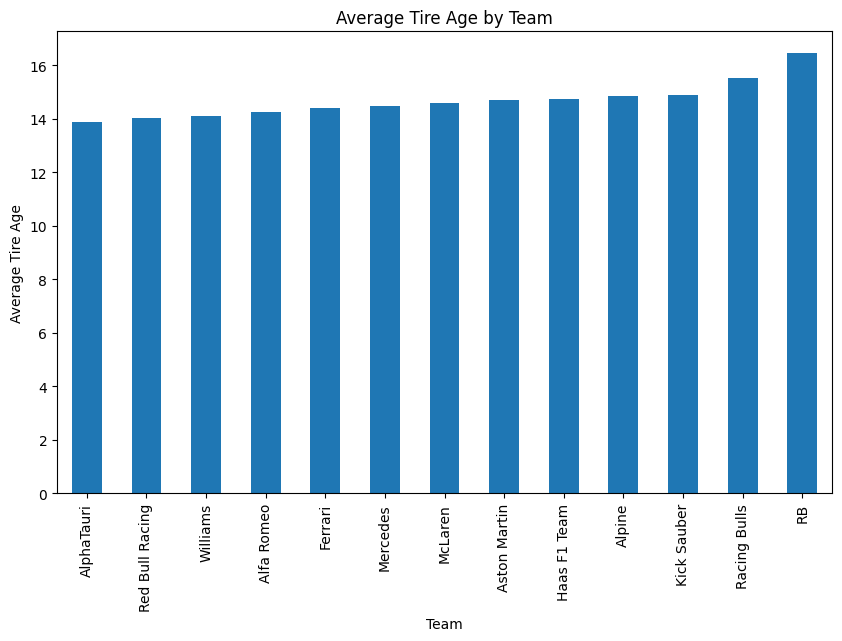

In [12]:
avg_age = (
    df.groupby("Team")["TireAge"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,6))
avg_age.plot(kind="bar")

plt.ylabel("Average Tire Age")
plt.title("Average Tire Age by Team")

plt.show()

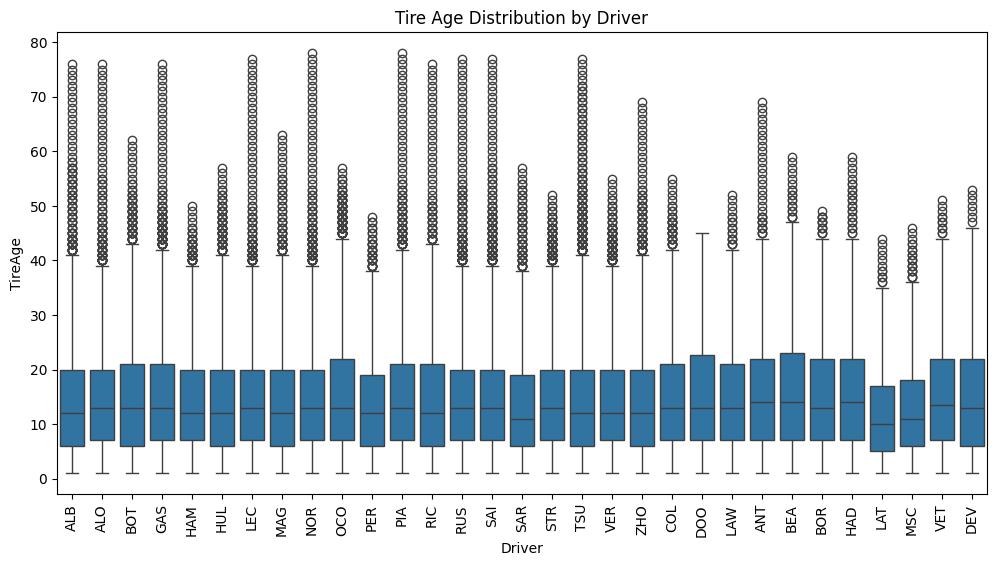

In [13]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="Driver",
    y="TireAge"
)

plt.xticks(rotation=90)

plt.title("Tire Age Distribution by Driver")

plt.show()

## Conclusion

- Drivers and teams display measurable differences in average pace and consistency.
- Certain teams consistently complete longer stints, suggesting differences in tire management strategies.
- Driver performance variability indicates that driving style may influence tire degradation.
- Team characteristics should therefore be considered during feature engineering.